# Geographic terrain source-coverage gate

**Numerical question.** Why did the registered 96-cell sample for the 1,826-cell finite-population terrain calculation stop before equivalent-area execution? This notebook reads the frozen failure record only. It does not calculate an equivalent area, a terrain-screen total, susceptibility, or hazard.

In [1]:
from pathlib import Path
import json, re
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
root = Path('..')
record = json.loads((root/'data/geographic_total/coverage_failure.json').read_text())
d = record['diagnosis']
assert record['equivalent_area_execution_called'] is False
assert d['complete_dem_support_count'] == 0
assert d['glacier_predicate_coverage_count'] == d['report_center_count']
assert d['outside_RGI_finite_PZI_count'] == d['outside_RGI_center_count']
objects = [(x, 0) for x in d['unavailable_dem_objects']] + [(x, 1) for x in d['available_halo_row_objects']]
source = {}
for name, available in objects:
    lat, lon = map(int, re.search(r'_N(\d+)_00_E(\d+)_00_', name).groups())
    source[lat, lon] = available
assert len(source) == 9 and sum(source.values()) == 3
{'cell': record['failure']['cell_key'], 'variant': record['failure']['variant'],
 'report_centers': d['report_center_count'], 'complete_dem_support': d['complete_dem_support_count'],
 'equivalent_area_called': record['equivalent_area_execution_called']}

{'cell': 'rgi7.0|global|south=+041|west=+0048',
 'variant': 'p00',
 'report_centers': 10303590,
 'complete_dem_support': 0,
 'equivalent_area_called': False}

RGI-predicate and finite-PZI coverage are complete at their registered denominators. The DEM condition fails because all six objects covering the reporting-cell latitude and its southern halo return HTTP 404; the three retained COGs cover only the northern halo row. The registered stop therefore makes the complete total non-estimable without treating missing support as zero or inspecting a partial equivalent-area result.

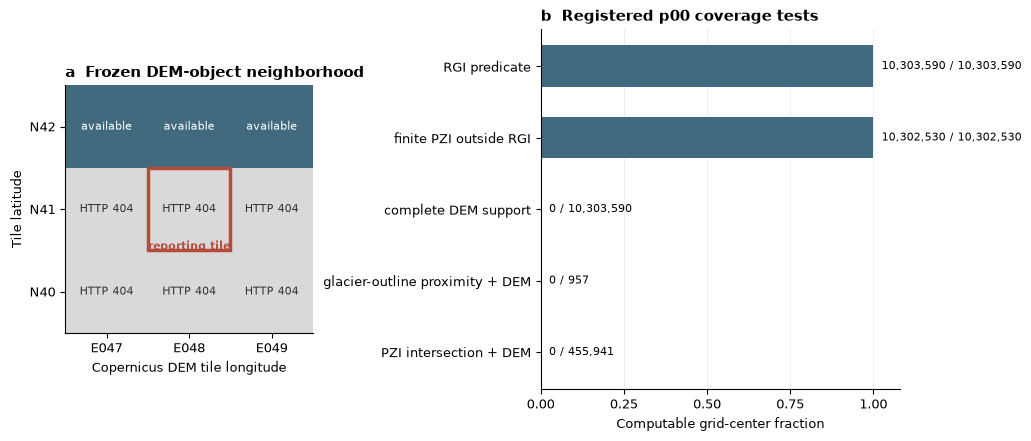

In [2]:
plt.rcParams.update({'font.size': 9, 'axes.spines.top': False, 'axes.spines.right': False})
fig, (ax, bx) = plt.subplots(1, 2, figsize=(10.2, 4.3), gridspec_kw={'width_ratios': [1, 1.45]}, constrained_layout=True)
lats, lons = [42, 41, 40], [47, 48, 49]
grid = np.array([[source[lat, lon] for lon in lons] for lat in lats])
ax.imshow(grid, cmap=ListedColormap(['#d9d9d9', '#426a7f']), vmin=0, vmax=1)
for i, lat in enumerate(lats):
    for j, lon in enumerate(lons): ax.text(j, i, 'available' if grid[i,j] else 'HTTP 404', ha='center', va='center', color='white' if grid[i,j] else '#333', fontsize=8)
ax.add_patch(plt.Rectangle((.5,.5), 1, 1, fill=False, edgecolor='#b44b3b', linewidth=2.5))
ax.set(xticks=range(3), xticklabels=[f'E{x:03d}' for x in lons], yticks=range(3), yticklabels=[f'N{x:02d}' for x in lats], xlabel='Copernicus DEM tile longitude', ylabel='Tile latitude')
ax.set_title('a  Frozen DEM-object neighborhood', loc='left', weight='bold')
ax.text(1, 1.38, 'reporting tile', ha='center', va='top', color='#b44b3b', fontsize=8, weight='bold')
labels = ['RGI predicate', 'finite PZI outside RGI', 'complete DEM support', 'glacier-outline proximity + DEM', 'PZI intersection + DEM']
num = np.array([d['glacier_predicate_coverage_count'], d['outside_RGI_finite_PZI_count'], d['complete_dem_support_count'], d['glacier_proximity_complete_dem_count'], d['PZI_mask_complete_dem_count']])
den = np.array([d['report_center_count'], d['outside_RGI_center_count'], d['report_center_count'], d['glacier_proximity_center_count'], d['PZI_mask_center_count']])
frac = num/den; y = np.arange(len(labels)); colors = ['#426a7f', '#426a7f', '#b44b3b', '#b44b3b', '#b44b3b']
bx.barh(y, frac, color=colors, height=.58); bx.set(yticks=y, yticklabels=labels, xlim=(0,1.08), xlabel='Computable grid-center fraction', xticks=[0,.25,.5,.75,1])
bx.invert_yaxis(); bx.grid(axis='x', color='#e4e7e9', linewidth=.5); bx.set_axisbelow(True)
for yi, f, a, b in zip(y, frac, num, den): bx.text(max(f+.025,.025), yi, f'{a:,} / {b:,}', va='center', fontsize=8)
bx.set_title('b  Registered p00 coverage tests', loc='left', weight='bold')
fig.savefig(root/'figures/geographic_coverage_gate.png', dpi=300, bbox_inches='tight')
fig.savefig(root/'figures/geographic_coverage_gate.pdf', bbox_inches='tight')
plt.show()